In [1]:
"""
Bethe-Bloch Energy Loss Calculator and Plotter
=============================================

This notebook implements the Bethe-Bloch formula for energy loss of charged particles
in matter with automatic material property lookup.

Formula: -dE/dx = K * z² * (Z/A) * (1/β²) * [ln(2mₑc²β²γ²Tₘₐₓ/I²) - β²]
"""

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Import our physics library
from lib import (
    material_db,
    calculate_bethe_bloch,
    calculate_specific_bethe_bloch_case
)

print("✓ Bethe-Bloch Calculator loaded successfully!")
print(f"  - Material database: {len(material_db.mean_excitation_energies)} elements + compounds available")
print("  - Ready for interactive Bethe-Bloch analysis")

✓ Particle Detectors Physics Library loaded successfully!
  - MaterialDatabase: 92 elements + 6 compounds
  - NuclearDatabase: 13 isotopes
  - Bethe-Bloch, neutron capture, and photon attenuation functions available
✓ Bethe-Bloch Calculator loaded successfully!
  - Material database: 92 elements + compounds available
  - Ready for interactive Bethe-Bloch analysis


# Bethe-Bloch Energy Loss Calculator

This notebook implements the **Bethe-Bloch formula** for calculating energy loss of charged particles passing through matter.

## Features

✨ **Automatic Material Lookup**: Select materials using chemical symbols (Si, Pb, Au, etc.) and the system automatically retrieves Z, A, and material properties

🧪 **Extensive Material Database**: Includes elements from the periodic table plus common compounds (Water, Air, Scintillators, etc.)

🎯 **Multiple Particle Types**: Pre-configured for muons, pions, protons, electrons with easy addition of new particles

📊 **Comprehensive Plotting**: Generate comparison plots for different materials and particles

⚡ **Interactive Calculations**: Functions for specific energy loss calculations

## The Bethe-Bloch Formula

$$-\frac{dE}{dx} = K z^2 \frac{Z}{A} \frac{1}{\beta^2} \left[ \ln\left(\frac{2m_e c^2 \beta^2 \gamma^2 T_{max}}{I^2}\right) - \beta^2 \right]$$

Where:
- $K = 4\pi N_A r_e^2 m_e c^2 = 0.307$ MeV⋅cm²/g  
- $z$ = charge of incident particle
- $Z, A$ = atomic number and mass of medium
- $\beta = v/c$, $\gamma = 1/\sqrt{1-\beta^2}$
- $I$ = mean excitation energy
- $T_{max}$ = maximum energy transfer in single collision

---

**📝 Instructions**: Modify the configuration variables at the top, then run all cells to generate plots!"

In [2]:
# ===================================================================
# CONFIGURATION SECTION - MODIFY THESE VARIABLES AS NEEDED
# ===================================================================

# Select materials to plot (chemical symbols or names)
SELECTED_MATERIALS = [
    'Si',        # Silicon
    'Ge',        # Germanium  
    'Ar',        # Argon
    'Al',        # Aluminum
    'Fe',        # Iron
    'Pb',        # Lead
    'C',         # Carbon (graphite)
    'Cu',        # Copper
]

# You can also use full names if mendeleev is available
SELECTED_MATERIAL_NAMES = [
    'Water',
    'Air', 
    'Scintillator'  # Organic scintillator
]

# Select particles to simulate
PARTICLES = [
    {'name': 'Muon', 'charge': 1, 'mass': 105.66},      # MeV/c²
    {'name': 'Pion', 'charge': 1, 'mass': 139.57},      # MeV/c²  
    {'name': 'Proton', 'charge': 1, 'mass': 938.27},    # MeV/c²
    {'name': 'Electron', 'charge': 1, 'mass': 0.511},   # MeV/c²
]

# Energy range for calculations
ENERGY_MIN = 1.0      # MeV
ENERGY_MAX = 10000.0  # MeV  
NUM_POINTS = 1000

print(f"Selected materials: {SELECTED_MATERIALS + SELECTED_MATERIAL_NAMES}")
print(f"Selected particles: {[p['name'] for p in PARTICLES]}")
print(f"Energy range: {ENERGY_MIN} - {ENERGY_MAX} MeV")

Selected materials: ['Si', 'Ge', 'Ar', 'Al', 'Fe', 'Pb', 'C', 'Cu', 'Water', 'Air', 'Scintillator']
Selected particles: ['Muon', 'Pion', 'Proton', 'Electron']
Energy range: 1.0 - 10000.0 MeV


In [3]:
# ===================================================================
# MATERIAL DATABASE INFO
# ===================================================================

# Display available materials from the imported material database
material_db.list_available_materials()

Available elements (first 10): ['H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', 'Ne', '... and more']
Available compounds: ['Water', 'Air', 'Scintillator', 'PMMA', 'Polyethylene', 'Steel']
⚠ Full periodic table available via mendeleev library


In [4]:
# ===================================================================
# CALCULATION FUNCTIONS (from lib.py)
# ===================================================================

# All heavy calculation functions are imported from lib.py:
# - calculate_bethe_bloch()
# - calculate_specific_bethe_bloch_case()

print("✓ Bethe-Bloch calculation functions loaded from lib.py")

✓ Bethe-Bloch calculation functions loaded from lib.py


In [5]:
# ===================================================================
# PLOTTING FUNCTIONS  
# ===================================================================

def plot_materials_comparison(particle, materials_list, energies):
    """Plot Bethe-Bloch for different materials with fixed particle."""
    
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(materials_list)))
    
    for material, color in zip(materials_list, colors):
        try:
            dEdx = calculate_bethe_bloch(energies, particle, material, material_db)
            
            # Plot only valid points
            valid_mask = ~np.isnan(dEdx) & (dEdx > 0)
            if np.any(valid_mask):
                plt.loglog(energies[valid_mask], dEdx[valid_mask], 
                          label=material, color=color, linewidth=2.5)
        except Exception as e:
            print(f"Warning: Could not calculate for {material}: {e}")
    
    plt.xlabel('Kinetic Energy (MeV)', fontsize=14)
    plt.ylabel(r'$-dE/dx$ (MeV·cm²/g)', fontsize=14)
    plt.title(f'Bethe-Bloch Energy Loss: {particle["name"]} in Different Materials', fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_particles_comparison(material, particles_list, energies):
    """Plot Bethe-Bloch for different particles in fixed material."""
    
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(particles_list)))
    
    for particle, color in zip(particles_list, colors):
        try:
            dEdx = calculate_bethe_bloch(energies, particle, material, material_db)
            
            # Plot only valid points
            valid_mask = ~np.isnan(dEdx) & (dEdx > 0)
            if np.any(valid_mask):
                label = f'{particle["name"]} (m={particle["mass"]:.1f} MeV/c²)'
                plt.loglog(energies[valid_mask], dEdx[valid_mask], 
                          label=label, color=color, linewidth=2.5)
        except Exception as e:
            print(f"Warning: Could not calculate for {particle['name']}: {e}")
    
    plt.xlabel('Kinetic Energy (MeV)', fontsize=14)
    plt.ylabel(r'$-dE/dx$ (MeV·cm²/g)', fontsize=14)
    plt.title(f'Bethe-Bloch Energy Loss: Different Particles in {material}', fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_comprehensive_grid(materials_list, particles_list, energies):
    """Create a comprehensive grid plot of all combinations."""
    
    n_materials = len(materials_list)
    n_particles = len(particles_list)
    
    fig, axes = plt.subplots(n_particles, n_materials, 
                            figsize=(4*n_materials, 3*n_particles),
                            sharex=True, sharey=True)
    
    if n_particles == 1:
        axes = axes.reshape(1, -1)
    if n_materials == 1:
        axes = axes.reshape(-1, 1)
    
    for i, particle in enumerate(particles_list):
        for j, material in enumerate(materials_list):
            ax = axes[i, j]
            
            try:
                dEdx = calculate_bethe_bloch(energies, particle, material, material_db)
                valid_mask = ~np.isnan(dEdx) & (dEdx > 0)
                
                if np.any(valid_mask):
                    ax.loglog(energies[valid_mask], dEdx[valid_mask], 'b-', linewidth=2)
                
                ax.set_title(f'{particle["name"]} in {material}', fontsize=11)
                ax.grid(True, alpha=0.3)
                
                if i == n_particles - 1:
                    ax.set_xlabel('Energy (MeV)', fontsize=10)
                if j == 0:
                    ax.set_ylabel(r'$-dE/dx$ (MeV·cm²/g)', fontsize=10)
            
            except Exception as e:
                ax.text(0.5, 0.5, f'Error:\n{str(e)[:30]}...', 
                       transform=ax.transAxes, ha='center', va='center')
    
    plt.tight_layout()
    plt.show()

def interactive_plotter():
    """Interactive function to quickly plot specific cases."""
    print("Interactive Bethe-Bloch Plotter")
    print("Available materials:", SELECTED_MATERIALS + SELECTED_MATERIAL_NAMES)
    print("Available particles:", [p['name'] for p in PARTICLES])
    
    material = input("Enter material name: ")
    particle_name = input("Enter particle name: ")
    
    # Find particle
    particle = None
    for p in PARTICLES:
        if p['name'].lower() == particle_name.lower():
            particle = p
            break
    
    if particle is None:
        print(f"Particle {particle_name} not found!")
        return
    
    # Generate energies and plot
    energies = np.logspace(np.log10(ENERGY_MIN), np.log10(ENERGY_MAX), NUM_POINTS)
    
    try:
        dEdx = calculate_bethe_bloch(energies, particle, material, material_db)
        valid_mask = ~np.isnan(dEdx) & (dEdx > 0)
        
        plt.figure(figsize=(10, 6))
        plt.loglog(energies[valid_mask], dEdx[valid_mask], 'b-', linewidth=2.5)
        plt.xlabel('Kinetic Energy (MeV)', fontsize=14)
        plt.ylabel(r'$-dE/dx$ (MeV·cm²/g)', fontsize=14)
        plt.title(f'Bethe-Bloch: {particle["name"]} in {material}', fontsize=16)
        plt.grid(True, alpha=0.3)
        plt.show()
        
    except Exception as e:
        print(f"Error: {e}")

print("✓ Plotting functions loaded")

✓ Plotting functions loaded


In [6]:
# ===================================================================
# GENERATE ENERGY ARRAY AND RUN CALCULATIONS
# ===================================================================

# Generate energy array for calculations
energies = np.logspace(np.log10(ENERGY_MIN), np.log10(ENERGY_MAX), NUM_POINTS)

print(f"Generated {NUM_POINTS} energy points from {ENERGY_MIN} to {ENERGY_MAX} MeV")
print(f"Ready to calculate Bethe-Bloch for {len(PARTICLES)} particles and {len(SELECTED_MATERIALS + SELECTED_MATERIAL_NAMES)} materials")

# Combine selected materials
all_materials = SELECTED_MATERIALS + SELECTED_MATERIAL_NAMES

print("\nSelected materials for plotting:")
for i, material in enumerate(all_materials, 1):
    try:
        Z, A, I, rho = material_db.get_material_properties(material)
        print(f"{i:2d}. {material:15s} (Z={Z:3.1f}, A={A:6.2f}, I={I:5.1f} eV)")
    except Exception as e:
        print(f"{i:2d}. {material:15s} - Error: {e}")

Generated 1000 energy points from 1.0 to 10000.0 MeV
Ready to calculate Bethe-Bloch for 4 particles and 11 materials

Selected materials for plotting:
 1. Si              (Z=14.0, A= 28.09, I=173.0 eV)
 2. Ge              (Z=32.0, A= 72.63, I=350.0 eV)
 3. Ar              (Z=18.0, A= 39.95, I=188.0 eV)
 4. Al              (Z=13.0, A= 26.98, I=166.0 eV)
 5. Fe              (Z=26.0, A= 55.84, I=286.0 eV)
 6. Pb              (Z=82.0, A=207.20, I=823.0 eV)
 7. C               (Z=6.0, A= 12.01, I= 78.0 eV)
 8. Cu              (Z=29.0, A= 63.55, I=322.0 eV)
 9. Water           (Z=10.0, A= 18.02, I= 75.0 eV)
10. Air             (Z=7.2, A= 14.40, I= 85.7 eV)
11. Scintillator    (Z=5.6, A= 11.90, I= 64.7 eV)



Plotting Muon in different materials...


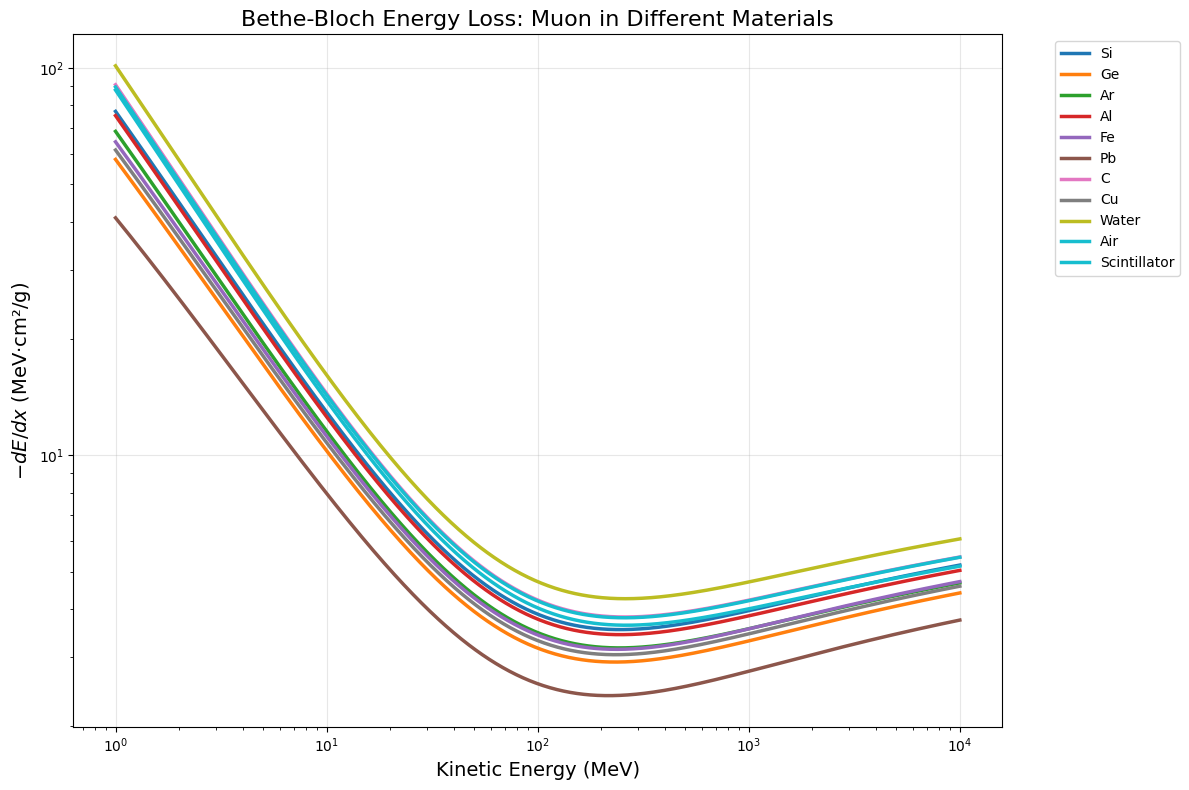


Plotting Pion in different materials...


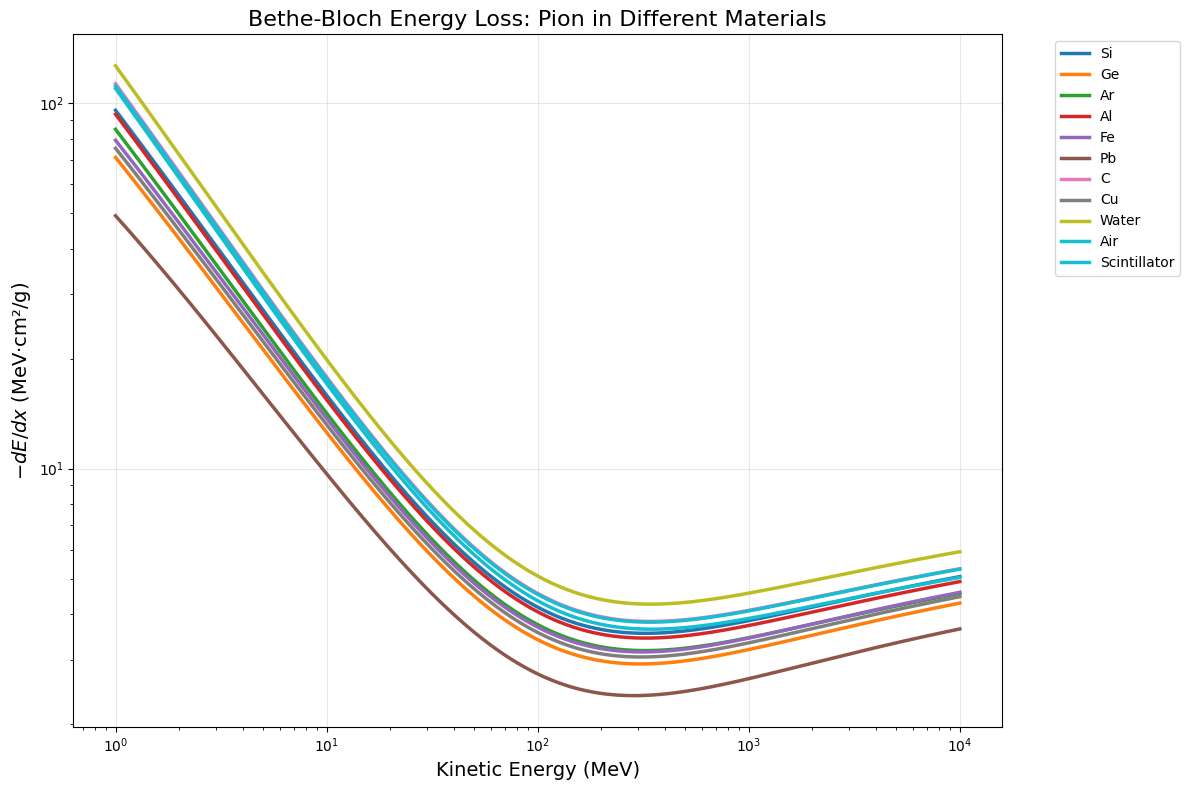


Plotting Proton in different materials...


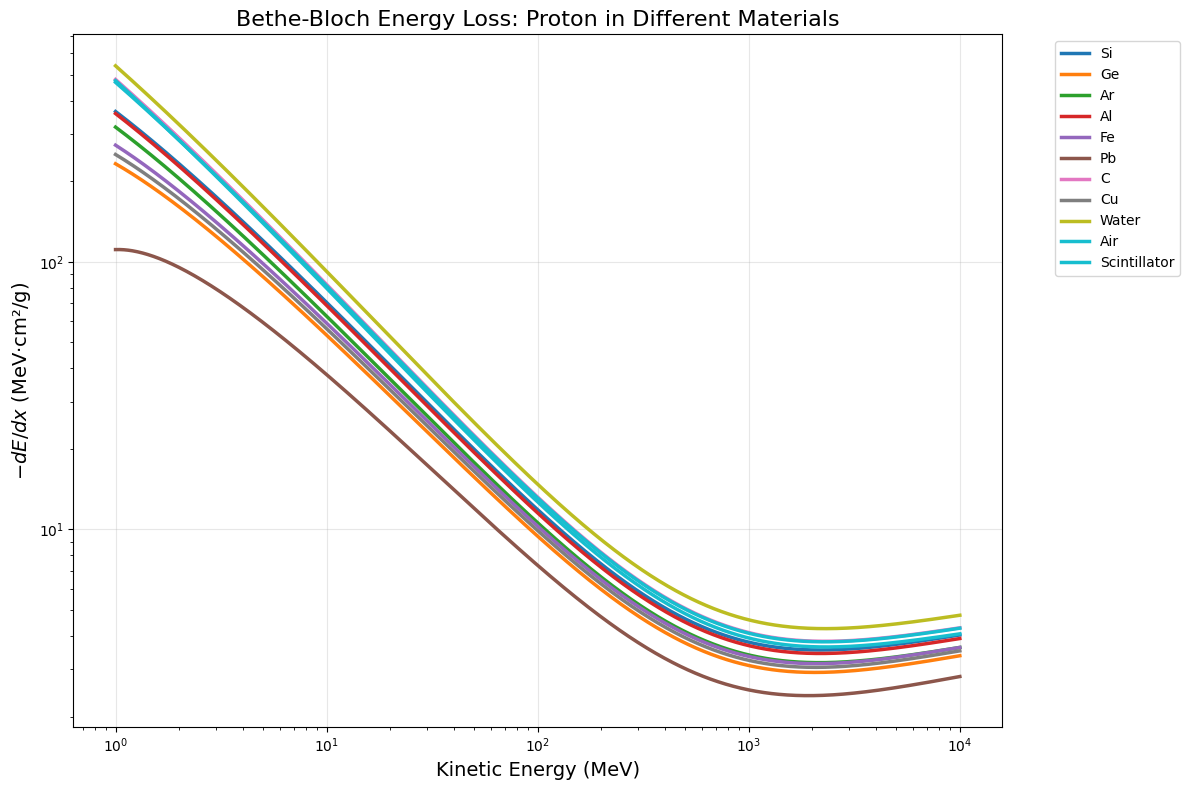


Plotting Electron in different materials...


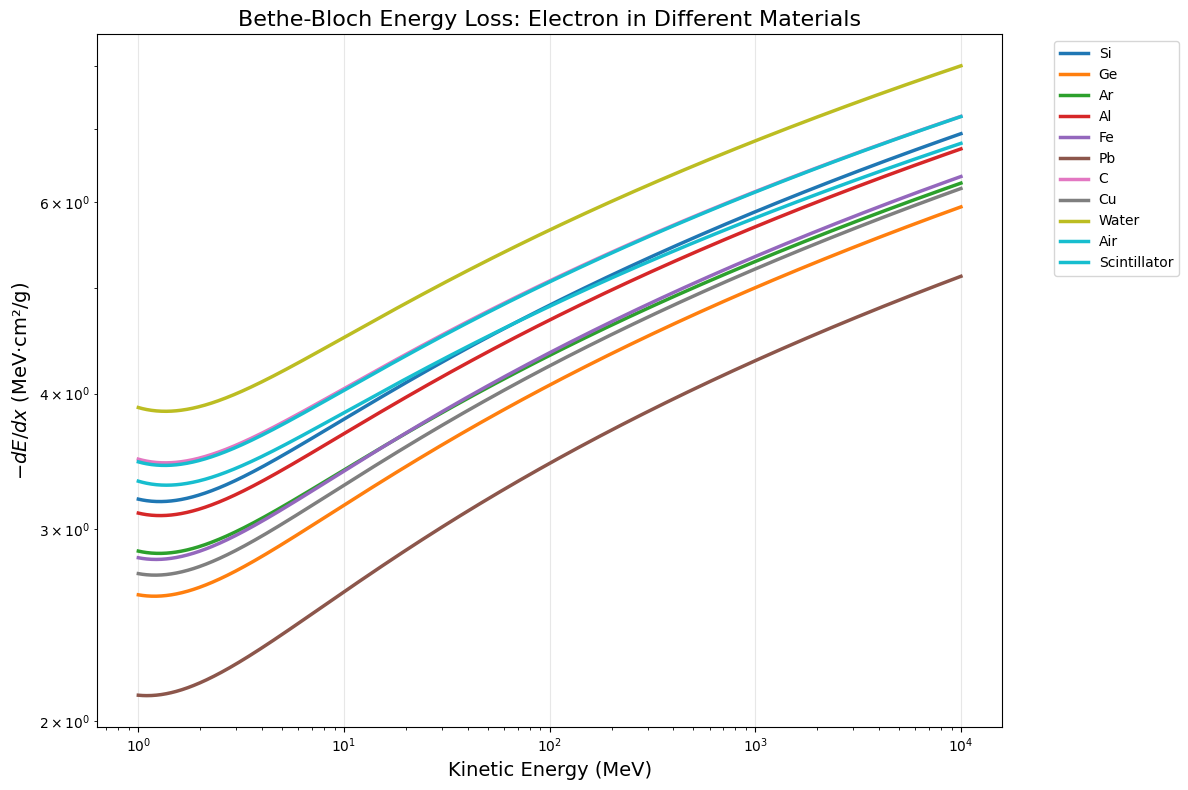

In [7]:
# ===================================================================
# PLOT 1: MATERIALS COMPARISON FOR EACH PARTICLE
# ===================================================================

# Plot Bethe-Bloch for different materials with each particle
for particle in PARTICLES:
    print(f"\nPlotting {particle['name']} in different materials...")
    plot_materials_comparison(particle, all_materials, energies)


Plotting different particles in Si...


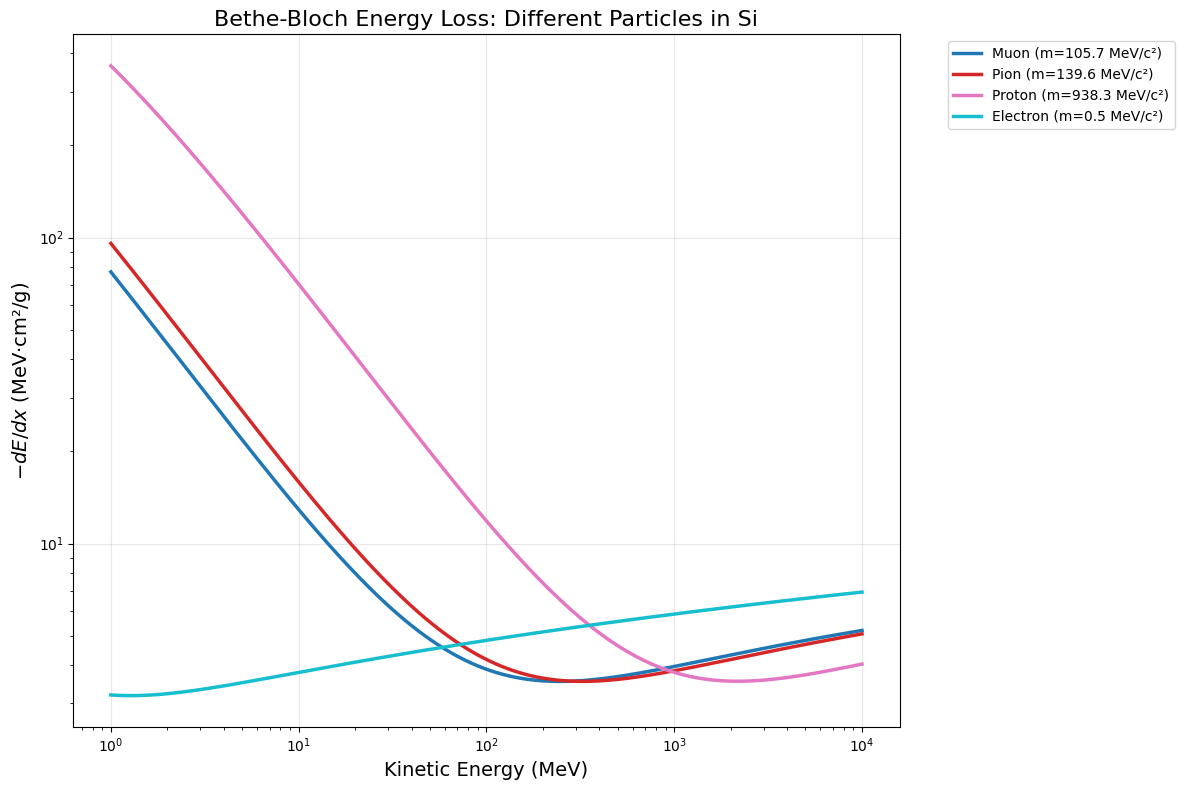


Plotting different particles in Ge...


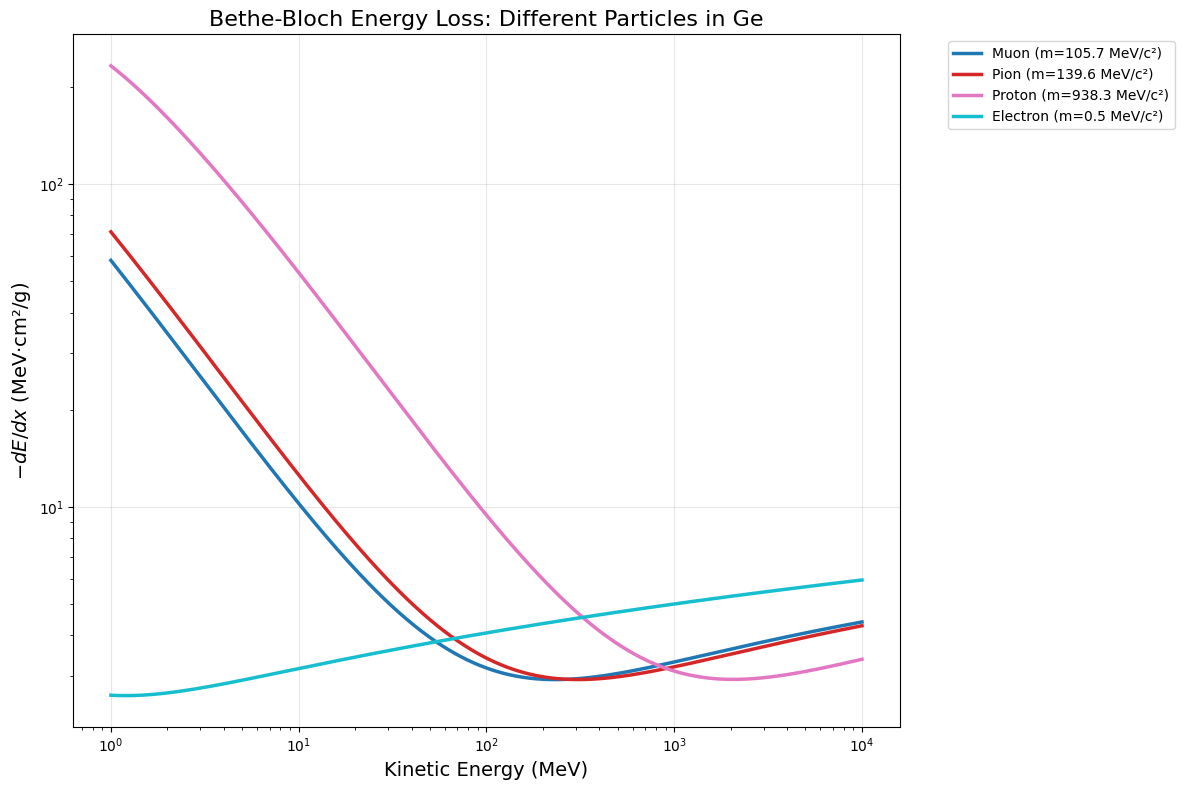


Plotting different particles in Ar...


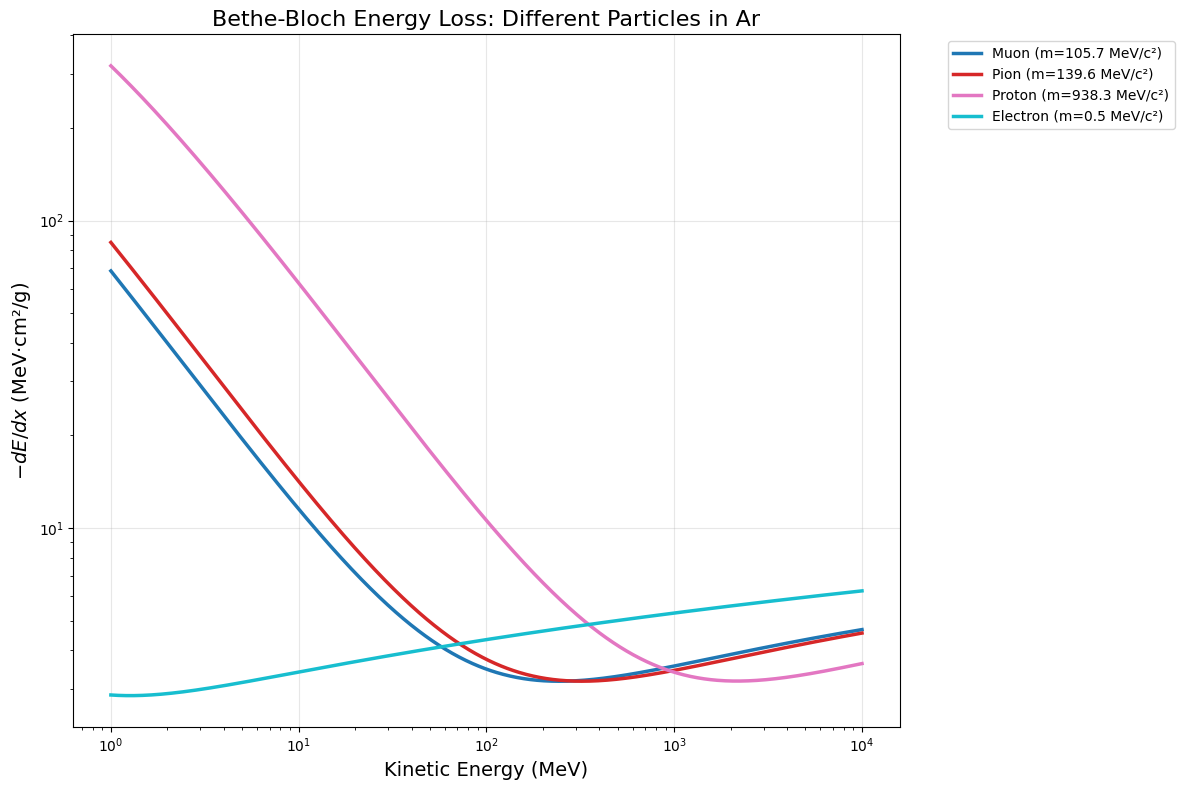


Plotting different particles in Al...


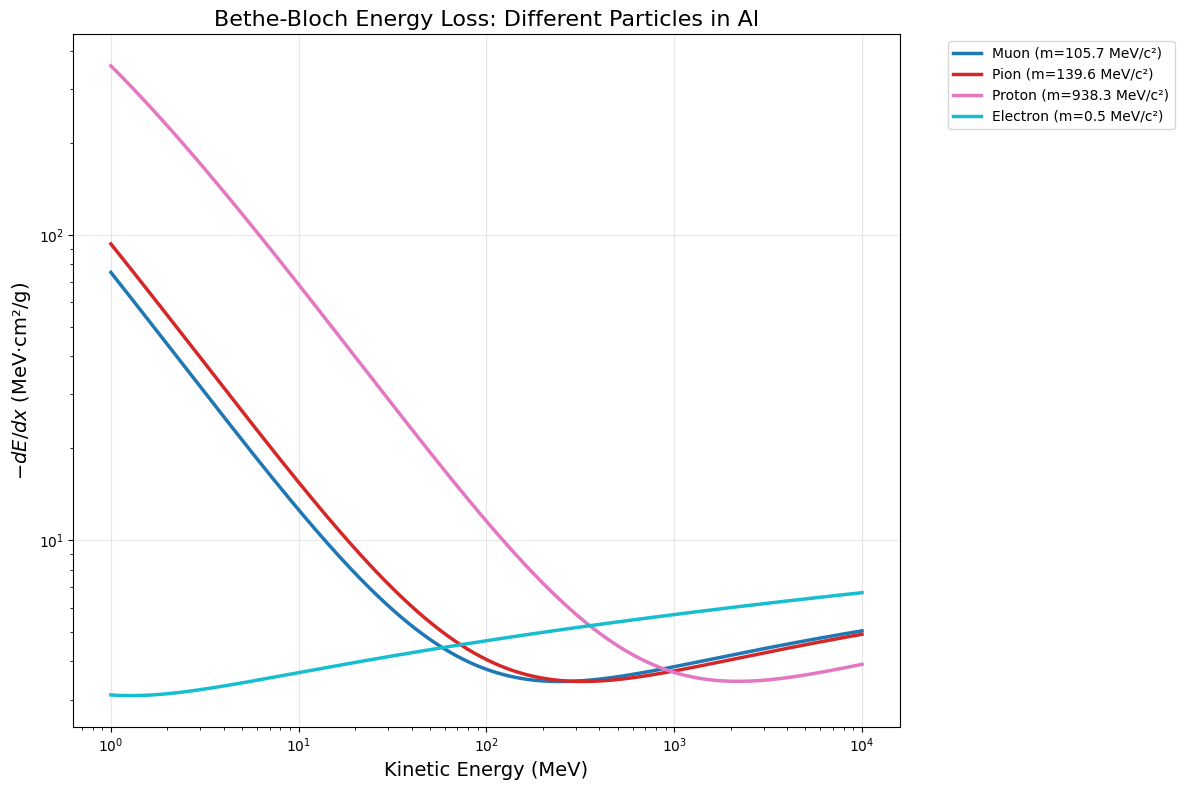


Plotting different particles in Fe...


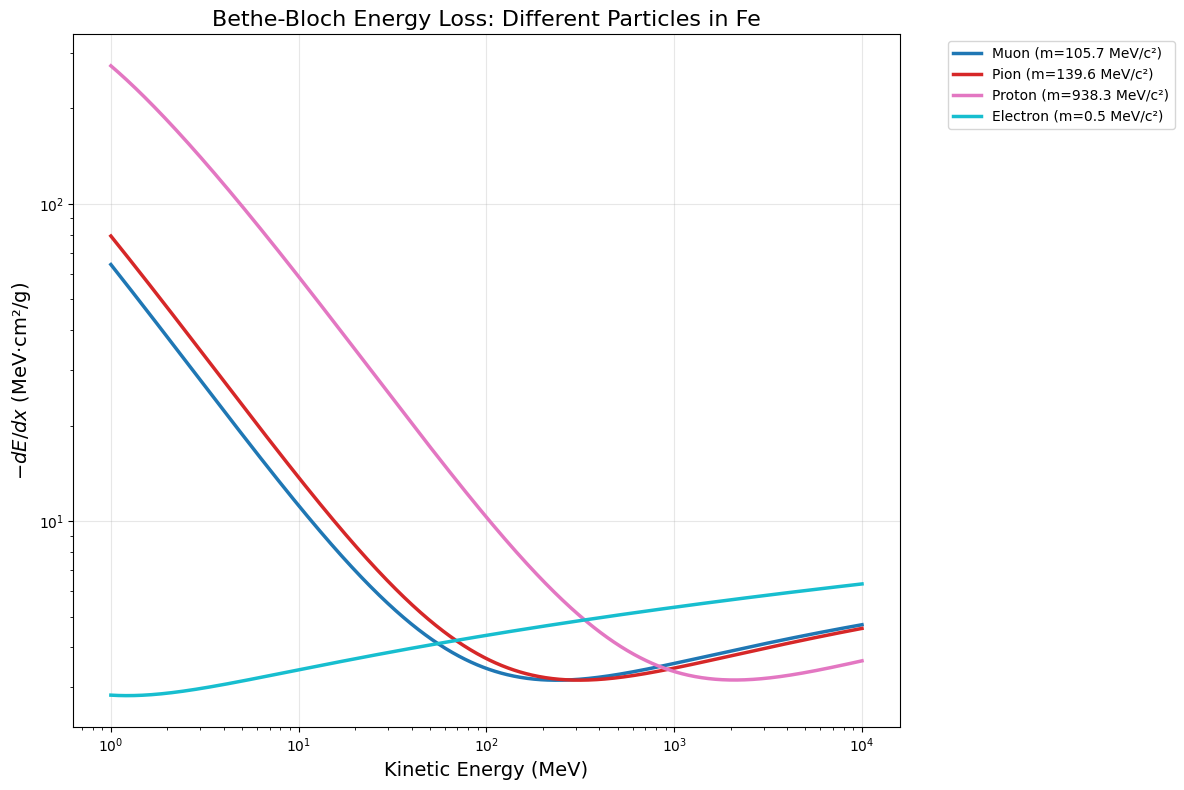

In [8]:
# ===================================================================
# PLOT 2: PARTICLES COMPARISON IN EACH MATERIAL
# ===================================================================

# Plot Bethe-Bloch for different particles in each material
for material in all_materials[:5]:  # Limit to first 5 materials to avoid too many plots
    print(f"\nPlotting different particles in {material}...")
    try:
        plot_particles_comparison(material, PARTICLES, energies)
    except Exception as e:
        print(f"Error plotting {material}: {e}")

In [9]:
# ===================================================================
# EXAMPLE CALCULATIONS
# ===================================================================

# Example specific calculations
print("EXAMPLE SPECIFIC CALCULATIONS")
print("=" * 60)

# Calculate some interesting cases
example_cases = [
    ("Muon", "Si", 1000.0),
    ("Proton", "Ar", 500.0),
    ("Electron", "Pb", 100.0),
    ("Pion", "Water", 200.0)
]

for particle_name, material, energy in example_cases:
    calculate_specific_bethe_bloch_case(particle_name, material, energy, PARTICLES, material_db)

EXAMPLE SPECIFIC CALCULATIONS

BETHE-BLOCH CALCULATION
Particle: Muon (mass = 105.66 MeV/c²)
Material: Si
Kinetic Energy: 1000.0 MeV
Energy Loss: 3.963 MeV·cm²/g
Material properties:
  Z = 14, A = 28.1 g/mol
  I = 173.0 eV, ρ = 2.330 g/cm³

BETHE-BLOCH CALCULATION
Particle: Proton (mass = 938.27 MeV/c²)
Material: Ar
Kinetic Energy: 500.0 MeV
Energy Loss: 4.149 MeV·cm²/g
Material properties:
  Z = 18, A = 39.9 g/mol
  I = 188.0 eV, ρ = 1.400 g/cm³

BETHE-BLOCH CALCULATION
Particle: Electron (mass = 0.511 MeV/c²)
Material: Pb
Kinetic Energy: 100.0 MeV
Energy Loss: 3.451 MeV·cm²/g
Material properties:
  Z = 82, A = 207.2 g/mol
  I = 823.0 eV, ρ = 11.350 g/cm³

BETHE-BLOCH CALCULATION
Particle: Pion (mass = 139.57 MeV/c²)
Material: Water
Kinetic Energy: 200.0 MeV
Energy Loss: 4.385 MeV·cm²/g
Material properties:
  Z = 10, A = 18.0 g/mol
  I = 75.0 eV, ρ = 1.000 g/cm³


In [10]:
# ===================================================================
# INTERACTIVE USE AND CUSTOMIZATION
# ===================================================================

print("\n" + "="*80)
print("BETHE-BLOCH CALCULATOR - READY FOR USE!")
print("="*80)

print("\n🎯 HOW TO USE THIS NOTEBOOK:")
print("1. Modify SELECTED_MATERIALS and PARTICLES in the configuration section")
print("2. Run all cells to generate plots")
print("3. Use calculate_specific_bethe_bloch_case(particle, material, energy) for individual calculations")
print("4. Use interactive_plotter() for on-demand plotting")

print("\n📚 AVAILABLE FUNCTIONS:")
print("• calculate_bethe_bloch(energies, particle, material, material_db)")
print("• calculate_specific_bethe_bloch_case(particle_name, material_name, energy_mev)")
print("• plot_materials_comparison(particle, materials_list, energies)")
print("• plot_particles_comparison(material, particles_list, energies)")
print("• plot_comprehensive_grid(materials_list, particles_list, energies)")
print("• interactive_plotter()")

print("\n🧪 TO ADD NEW MATERIALS:")
print("• For elements: Just use chemical symbol (e.g., 'Au', 'Ti')")
print("• Mendeleev library automatically provides Z, A, and density (if available)")
print("• For compounds: Add to compound_database in MaterialDatabase class in lib.py")

print("\n🚀 TO ADD NEW PARTICLES:")
print("• Add to PARTICLES list with: {'name': 'ParticleName', 'charge': z, 'mass': mass_MeV}")

print("\n💡 EXAMPLE USAGE:")
print("# Calculate muon energy loss in silicon at 1 GeV")
print("particle = {'name': 'Muon', 'charge': 1, 'mass': 105.66}")
print("dEdx = calculate_bethe_bloch([1000], particle, 'Si', material_db)")
print("print(f'Energy loss: {dEdx[0]:.3f} MeV·cm²/g')")

print("\n# Quick specific calculation")  
print("calculate_specific_bethe_bloch_case('Muon', 'Si', 1000.0)")

print("\n" + "="*80)

# Uncomment the line below to run the interactive plotter
# interactive_plotter()


BETHE-BLOCH CALCULATOR - READY FOR USE!

🎯 HOW TO USE THIS NOTEBOOK:
1. Modify SELECTED_MATERIALS and PARTICLES in the configuration section
2. Run all cells to generate plots
3. Use calculate_specific_bethe_bloch_case(particle, material, energy) for individual calculations
4. Use interactive_plotter() for on-demand plotting

📚 AVAILABLE FUNCTIONS:
• calculate_bethe_bloch(energies, particle, material, material_db)
• calculate_specific_bethe_bloch_case(particle_name, material_name, energy_mev)
• plot_materials_comparison(particle, materials_list, energies)
• plot_particles_comparison(material, particles_list, energies)
• plot_comprehensive_grid(materials_list, particles_list, energies)
• interactive_plotter()

🧪 TO ADD NEW MATERIALS:
• For elements: Just use chemical symbol (e.g., 'Au', 'Ti')
• Mendeleev library automatically provides Z, A, and density (if available)
• For compounds: Add to compound_database in MaterialDatabase class in lib.py

🚀 TO ADD NEW PARTICLES:
• Add to PARTICLE

In [12]:
# Basic use: set materials, get value

test_material = 'Si'
test_particle = {'name': 'Muon', 'charge': 1, 'mass': 105.66}  # MeV/c²
test_energy = 1000.0 # MeV
dEdx = calculate_bethe_bloch([test_energy], test_particle, test_material, material_db)

print(f"Energy loss for {test_particle['name']} in {test_material} at {test_energy} MeV: {dEdx[0]:.3f} MeV·cm²/g")
# now considering per cm in in the chosen material
print(f"Energy loss per cm in {test_material}: {dEdx[0] * material_db.get_material_properties(test_material)[3]:.3f} MeV/cm")


Energy loss for Muon in Si at 1000.0 MeV: 3.963 MeV·cm²/g
Energy loss per cm in Si: 9.234 MeV/cm
